<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Stock_Project2_Advanced_Cleaning_Model_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Advanced Data Cleaning and Transformation for Stock Market Modeling

This notebook prepares the **Daily Historical Stock Prices (1970-2018)** dataset for advanced analysis and machine learning. It builds on Project 1 by applying advanced imputation, outlier treatment, error correction, feature engineering, scaling, encoding, temporal splitting, and saving model-ready files.

In [16]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile, warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler

## 2. Load the dataset
The dataset contains `historical_stock_prices.csv` and `historical_stocks.csv`. The price file is large, so this notebook uses chunk-based loading. To process more data, increase the number of chunks or remove the break.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd

stocks_path = "/content/drive/MyDrive/Willis_doc/historical_stocks.csv"
prices_path = "/content/drive/MyDrive/Willis_doc/historical_stock_prices.csv"

stocks = pd.read_csv(stocks_path)
prices = pd.read_csv(prices_path, nrows=100000)

stocks.head()

,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


## 3. Initial data quality audit
This step checks missing values, duplicate entries, data types, and invalid values before cleaning.

In [20]:
print("Missing values before cleaning:")
display(prices.isna().sum())
print("Duplicate rows:", prices.duplicated().sum())
print("Data types:")
display(prices.dtypes)

Missing values before cleaning:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0


Duplicate rows: 0
Data types:


,0
ticker,object
open,float64
close,float64
adj_close,float64
low,float64
high,float64
volume,int64
date,object


## 4. Advanced data cleaning
Missing numeric values are treated using ticker-level interpolation followed by forward/backward filling. OHLC errors are corrected by recalculating High and Low from the available OHLC values.

In [22]:
prices.columns = prices.columns.str.lower().str.strip()
stocks.columns = stocks.columns.str.lower().str.strip()
prices = prices.drop_duplicates()

price_cols = ["open", "close", "adj_close", "low", "high"]
for c in price_cols:
    prices[c] = pd.to_numeric(prices[c], errors="coerce")

# Correct price-structure errors
prices["high"] = prices[["open", "close", "low", "high"]].max(axis=1)
prices["low"] = prices[["open", "close", "low", "high"]].min(axis=1)
prices["volume"] = pd.to_numeric(prices["volume"], errors="coerce")

prices = prices.sort_values(["ticker", "date"])

for c in price_cols + ["volume"]:
    prices[c] = prices.groupby("ticker", observed=True)[c].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )
    prices[c] = prices.groupby("ticker", observed=True)[c].transform(lambda s: s.ffill().bfill())

prices = prices.dropna(subset=["ticker", "date", "close"])
prices = prices[prices["volume"] >= 0]
prices["date"] = pd.to_datetime(prices["date"], errors="coerce")

prices["decade"] = (prices["date"].dt.year // 10 * 10).astype(int).astype(str) + "s"
prices["year"] = prices["date"].dt.year
prices["month"] = prices["date"].dt.to_period("M").astype(str)

print("Shape after cleaning:", prices.shape)
display(prices.head())

Shape after cleaning: (100000, 11)


,ticker,open,close,adj_close,low,high,volume,date,decade,year,month
948,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,1980-12-12,1980s,1980,1980-12
960,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,1980-12-15,1980s,1980,1980-12
968,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,1980-12-16,1980s,1980,1980-12
980,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,1980-12-17,1980s,1980,1980-12
988,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,1980-12-18,1980s,1980,1980-12


## 5. Outlier detection and treatment
Close price and Volume are critical variables. The IQR method is applied by decade, and outliers are capped instead of deleted to preserve time-series continuity.

In [23]:
def cap_iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return s.clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

prices["close_clean"] = prices.groupby("decade")["close"].transform(cap_iqr)
prices["volume_clean"] = prices.groupby("decade")["volume"].transform(cap_iqr)

outlier_rows = ((prices["close"] != prices["close_clean"]) |
                (prices["volume"] != prices["volume_clean"])).sum()
print("Rows affected by outlier capping:", outlier_rows)

Rows affected by outlier capping: 17944


## 6. Merge sector information
The price data is merged with stock metadata to include exchange, sector, and industry information.

In [24]:
stocks = stocks[["ticker", "exchange", "sector", "industry"]].drop_duplicates("ticker")
df = prices.merge(stocks, on="ticker", how="left")
df[["exchange", "sector", "industry"]] = df[["exchange", "sector", "industry"]].fillna("Unknown")
display(df.head())

,ticker,open,close,adj_close,low,high,volume,date,decade,year,month,close_clean,volume_clean,exchange,sector,industry
0,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,1980-12-12,1980s,1980,1980-12,0.513393,29344200.0,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
1,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,1980-12-15,1980s,1980,1980-12,0.486607,29344200.0,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
2,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,1980-12-16,1980s,1980,1980-12,0.450893,26432000.0,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
3,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,1980-12-17,1980s,1980,1980-12,0.462054,21610400.0,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
4,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,1980-12-18,1980s,1980,1980-12,0.475446,18362400.0,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING


## 7. Feature engineering
New features include returns, rolling averages, rolling volatility, price range, relative range, volume change, and next-day return target.

In [25]:
df = df.sort_values(["ticker", "date"])
df["daily_return"] = df.groupby("ticker", observed=True)["close_clean"].pct_change().replace([np.inf, -np.inf], np.nan)
df["log_return"] = np.log(df["close_clean"] / df.groupby("ticker", observed=True)["close_clean"].shift(1)).replace([np.inf, -np.inf], np.nan)
df["ma_20"] = df.groupby("ticker", observed=True)["close_clean"].transform(lambda s: s.rolling(20, min_periods=5).mean())
df["ma_60"] = df.groupby("ticker", observed=True)["close_clean"].transform(lambda s: s.rolling(60, min_periods=10).mean())
df["volatility_20"] = df.groupby("ticker", observed=True)["daily_return"].transform(lambda s: s.rolling(20, min_periods=5).std())
df["price_range"] = df["high"] - df["low"]
df["range_pct"] = df["price_range"] / df["close_clean"].replace(0, np.nan)
df["volume_change"] = df.groupby("ticker", observed=True)["volume_clean"].pct_change().replace([np.inf, -np.inf], np.nan)
df["target_next_day_return"] = df.groupby("ticker", observed=True)["daily_return"].shift(-1)

df = df.dropna(subset=["daily_return", "ma_20", "ma_60", "volatility_20", "target_next_day_return"])
print("Feature-engineered dataset shape:", df.shape)
display(df.head())

Feature-engineered dataset shape: (99700, 25)


,ticker,open,close,adj_close,low,high,volume,date,decade,year,...,industry,daily_return,log_return,ma_20,ma_60,volatility_20,price_range,range_pct,volume_change,target_next_day_return
9,AAPL,0.633929,0.633929,0.028630,0.633929,0.636161,13893600,1980-12-26,1980s,1980,...,COMPUTER MANUFACTURING,0.092308,0.088293,0.518750,0.518750,0.053737,0.002232,0.003521,0.157723,0.014084
10,AAPL,0.642857,0.642857,0.029033,0.642857,0.645089,23290400,1980-12-29,1980s,1980,...,COMPUTER MANUFACTURING,0.014084,0.013986,0.530032,0.530032,0.050781,0.002232,0.003472,0.676340,-0.024306
11,AAPL,0.629464,0.627232,0.028328,0.627232,0.629464,17220000,1980-12-30,1980s,1980,...,COMPUTER MANUFACTURING,-0.024306,-0.024606,0.538132,0.538132,0.050321,0.002232,0.003559,-0.260640,-0.028470
12,AAPL,0.611607,0.609375,0.027521,0.609375,0.611607,8937600,1980-12-31,1980s,1980,...,COMPUTER MANUFACTURING,-0.028470,-0.028883,0.543613,0.543613,0.049940,0.002232,0.003663,-0.480976,0.010989
13,AAPL,0.616071,0.616071,0.027824,0.616071,0.620536,5415200,1981-01-02,1980s,1981,...,COMPUTER MANUFACTURING,0.010989,0.010929,0.548788,0.548788,0.047830,0.004464,0.007246,-0.394110,-0.021739


## 8. Normalization and categorical encoding
Numerical variables are standardized using z-score scaling. Sector and exchange are one-hot encoded for machine learning.

In [26]:
num_features = ["open", "high", "low", "close_clean", "volume_clean", "daily_return", "log_return",
                "ma_20", "ma_60", "volatility_20", "price_range", "range_pct", "volume_change"]

scaler = StandardScaler()
scaled = scaler.fit_transform(df[num_features].replace([np.inf, -np.inf], np.nan).fillna(0))
scaled_df = pd.DataFrame(scaled, columns=[f"{c}_z" for c in num_features], index=df.index)

model_df = pd.concat([df.reset_index(drop=True), scaled_df.reset_index(drop=True)], axis=1)
model_df = pd.get_dummies(model_df, columns=["sector", "exchange"], drop_first=True)

print("Model-ready shape:", model_df.shape)

Model-ready shape: (99700, 47)


## 9. Train, validation, and test split
A time-based split avoids look-ahead bias. The earliest 70% becomes training data, the next 15% validation, and the final 15% test data.

In [27]:
model_df = model_df.sort_values("date")
n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (69790, 47)
Validation: (14955, 47)
Test: (14955, 47)


## 10. Visualizations and statistical analysis

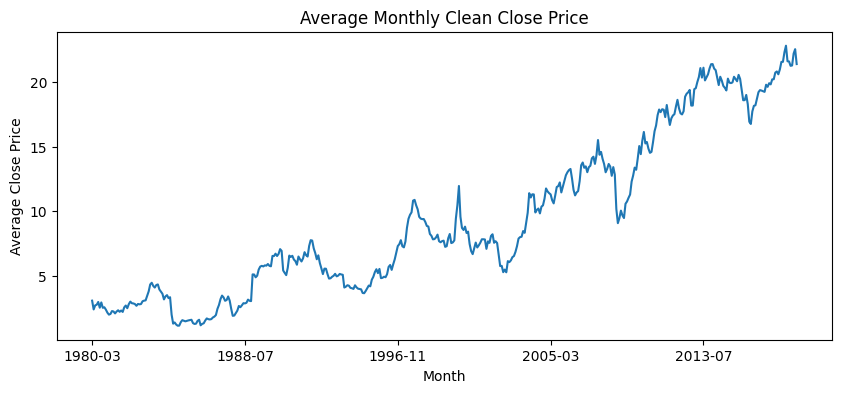

,records,tickers,mean_close,median_close,std_close,mean_volume,mean_volatility
decade,,,,,,,
1980s,7787,6,2.948834,1.4375,3.179932,7.041361e+06,0.023343
1990s,15702,12,6.711949,5.6250,5.366734,2.725681e+05,0.030377
2000s,35091,21,10.800306,8.8900,8.141585,4.115616e+05,0.035299
2010s,41120,24,19.129336,15.7000,13.300746,4.521233e+05,0.020713


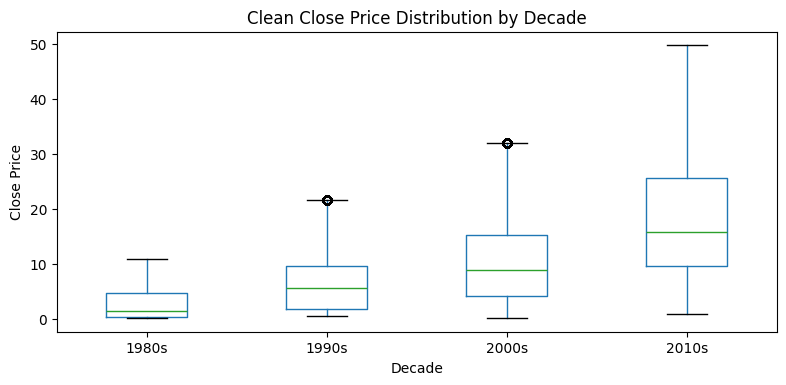

In [28]:
monthly = df.groupby("month")["close_clean"].mean()
plt.figure(figsize=(10, 4))
monthly.plot()
plt.title("Average Monthly Clean Close Price")
plt.xlabel("Month")
plt.ylabel("Average Close Price")
plt.show()

dec_summary = df.groupby("decade").agg(
    records=("ticker", "size"),
    tickers=("ticker", "nunique"),
    mean_close=("close_clean", "mean"),
    median_close=("close_clean", "median"),
    std_close=("close_clean", "std"),
    mean_volume=("volume_clean", "mean"),
    mean_volatility=("volatility_20", "mean")
)
display(dec_summary)

df.boxplot(column="close_clean", by="decade", figsize=(9, 4), grid=False)
plt.suptitle("")
plt.title("Clean Close Price Distribution by Decade")
plt.xlabel("Decade")
plt.ylabel("Close Price")
plt.show()

## 11. Save cleaned data and splits

In [29]:
model_df.to_csv("clean_stock_model_ready.csv", index=False)
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("validation_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)
print("Files saved successfully.")

Files saved successfully.


## 12. Conclusion
The dataset is now cleaned, corrected, transformed, normalized, encoded, and split for future predictive modeling. The engineered target `target_next_day_return` supports regression modeling, while a classification target can also be created by labeling positive versus negative next-day returns.